# Експеримент 04: Базова модель SVM для класифікації тем

## Мета
Створити baseline модель для класифікації новин за 5 темами:
- політика
- спорт
- новини
- технології
- бізнес

## Підхід
LinearSVC з CalibratedClassifierCV + TF-IDF (unigrams + bigrams) + лематизація

In [1]:
# Імпорт бібліотек
import os
import sys
import json
import random
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Для лематизації українського тексту
import pymorphy3
import re

# Імпорт утиліт
# # # # sys.path.append('..')  # Not needed  # Not needed  # Not needed  # Not needed
from utils.experiment_utils import *

# Налаштування відображення
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Шляхи
dataset_path = r"C:\Users\igrew\OneDrive\Desktop\Course Work\Datasets\theme_detector\ua_news_train_balanced.csv"
models_dir = 'saved_models/'
plots_dir = 'plots/'
results_dir = 'results/'

assert os.path.exists(dataset_path), f"Датасет не знайдено: {dataset_path}"

os.makedirs(models_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

print("Середовище підготовлено")

Середовище підготовлено


## 1. Завантаження даних

In [3]:
df = pd.read_csv(dataset_path)
print(f"Розмір датасету: {df.shape}")
print(f"\nКолонки: {df.columns.tolist()}")
print(f"\nРозподіл класів:\n{df['target'].value_counts()}")
print(f"\nПриклади:")
df.head()

Розмір датасету: (50000, 4)

Колонки: ['title', 'text', 'tags', 'target']

Розподіл класів:
target
політика      10000
спорт         10000
новини        10000
технології    10000
бізнес        10000
Name: count, dtype: int64

Приклади:


,title,text,tags,target
0,"Бойовики ""ДНР"" застрелили російського офіцера",Про це повідомляє Головне управління розвідки ...,|бойовики|Новини|розвідка|ДНР|,політика
1,"Італія забила шість голів Ліхтенштейну, Іспані...","У групах D, F і G відбулись матчі другого туру...",Євро-2020|Сборная Испании|Сборная Италии|Збірн...,спорт
2,Перший після Налбандяна. Шварцман виграв титул...,Аргентинець Дієго Шварцман став переможцем гру...,Теніс|Atp|Франсиско Серундоло|Atp Буенос-айрес...,спорт
3,Цими вихідними киян позбавлять води,"Про це повідомляє прес-центр ""Київводоканалу""....",|Київська область|Київ|Новини|вода|,новини
4,"""Нічого страшного"": В Кремлі прокоментували ф...","Про це повідомляє російський телеканал ""Дождь""...",|курйози|Кремль|ІД|Дмитро Пєсков|Росія|Новини|...,політика


## 2. Препроцесинг тексту

In [ ]:
with open('C:/Users/igrew/OneDrive/Desktop/Course Work/stopwords_ua.txt', 'r', encoding='utf-8') as f:
    ukrainian_stopwords  = set(f.read().splitlines())

morph = pymorphy3.MorphAnalyzer(lang='uk')

lemma_cache = {}

def preprocess_text(sentence):
    words = sentence.split()
    lemmas = []
    for word in words:
        if word not in lemma_cache:
            lemma_cache[word] = morph.parse(word)[0].normal_form
        lemmas.append(lemma_cache[word])
    return ' '.join(lemmas)


print("Функція препроцесингу визначена")
print(f"\nПриклад препроцесингу:")
sample_text = df['text'].iloc[0]
print(f"Оригінал: {sample_text[:200]}...")
print(f"Після обробки: {preprocess_text(sample_text)[:200]}...")

Функція препроцесингу визначена

Приклад препроцесингу:
Оригінал: Про це повідомляє Головне управління розвідки Міністерства оборони України. У розвідці зазначили, що це пов'язано з фізичним та психологічним навантаженням від тривалого перебування на передових позиц...
Після обробки: про це повідомляти головний управління розвідка міністерство оборона україни. у розвідка зазначили, що це пов'язати з фізичний та психологічний навантаження від тривалий перебування на передовий позиц...


In [11]:
print("Застосування препроцесингу до всього датасету...")
df['text_processed'] = [preprocess_text(text) for text in tqdm(df['text'], desc="Preprocessing")]
print("Препроцесинг завершено")

Застосування препроцесингу до всього датасету...


Preprocessing:   0%|          | 0/50000 [00:00<?, ?it/s]

Препроцесинг завершено


## 3. Розбиття на train/test (80/20)

In [12]:
# Підготовка даних
X = df['text_processed'].values
y = df['target'].values

# Розбиття зі стратифікацією
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"\nTrain розподіл:")
unique, counts = np.unique(y_train, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  {label}: {count}")
print(f"\nTest розподіл:")
unique, counts = np.unique(y_test, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  {label}: {count}")

Train: 40000 | Test: 10000

Train розподіл:
  бізнес: 8000
  новини: 8000
  політика: 8000
  спорт: 8000
  технології: 8000

Test розподіл:
  бізнес: 2000
  новини: 2000
  політика: 2000
  спорт: 2000
  технології: 2000


## 4. Векторизація TF-IDF з біграмами

In [13]:
# Створення TF-IDF векторизатора з біграмами
vectorizer = TfidfVectorizer(
    max_features=30000,  
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.85,
    sublinear_tf=True,  
    use_idf=True,
    smooth_idf=True
)

print("Векторизація train...")
X_train_tfidf = vectorizer.fit_transform(X_train)
print("Векторизація test...")
X_test_tfidf = vectorizer.transform(X_test)

print(f"\nРозмір TF-IDF матриці:")
print(f"Train: {X_train_tfidf.shape}")
print(f"Test: {X_test_tfidf.shape}")

Векторизація train...
Векторизація test...

Розмір TF-IDF матриці:
Train: (40000, 30000)
Test: (10000, 30000)


## 5. Тренування LinearSVC з калібрацією

In [ ]:
print("Тренування LinearSVC...")
base_svm = LinearSVC(
    random_state=SEED, 
    max_iter=2000, 
    dual=False)
model = CalibratedClassifierCV(base_svm, cv=3)

model.fit(X_train_tfidf, y_train)
print("Тренування завершено")

Тренування LinearSVC...
Тренування завершено


## 6. Оцінка моделі

In [15]:
# Передбачення на тестовій вибірці
y_pred = model.predict(X_test_tfidf)

# Обчислення метрик
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')
per_class_f1 = f1_score(y_test, y_pred, average=None)

print("=" * 50)
print("РЕЗУЛЬТАТИ SVM BASELINE")
print("=" * 50)
print(f"Accuracy: {accuracy:.4f}")
print(f"Macro-F1: {macro_f1:.4f}")
print(f"Weighted-F1: {weighted_f1:.4f}")

# Per-class метрики
classes = np.unique(y_train)
print(f"\nF1-score по класам:")
for cls, f1 in zip(classes, per_class_f1):
    print(f"  {cls}: {f1:.4f}")

# Детальний звіт
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=classes))

РЕЗУЛЬТАТИ SVM BASELINE
Accuracy: 0.9213
Macro-F1: 0.9209
Weighted-F1: 0.9209

F1-score по класам:
  бізнес: 0.9318
  новини: 0.8552
  політика: 0.8840
  спорт: 0.9880
  технології: 0.9456

=== Classification Report ===
              precision    recall  f1-score   support

      бізнес       0.92      0.94      0.93      2000
      новини       0.87      0.84      0.86      2000
    політика       0.89      0.88      0.88      2000
       спорт       0.99      0.99      0.99      2000
  технології       0.93      0.96      0.95      2000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



## 7. Візуалізація: Confusion Matrix

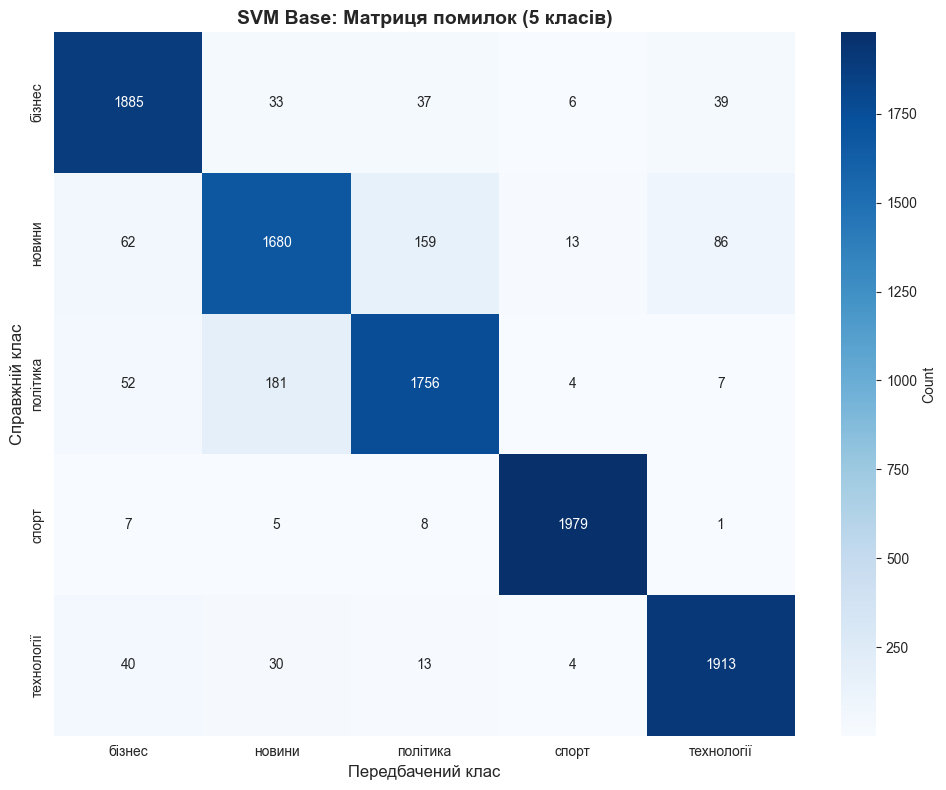

In [16]:
cm = confusion_matrix(y_test, y_pred, labels=classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, cbar_kws={'label': 'Count'})
plt.xlabel('Передбачений клас', fontsize=12)
plt.ylabel('Справжній клас', fontsize=12)
plt.title('SVM Base: Матриця помилок (5 класів)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{plots_dir}04_topic_svm_base_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## 8. Візуалізація: F1-score по класах

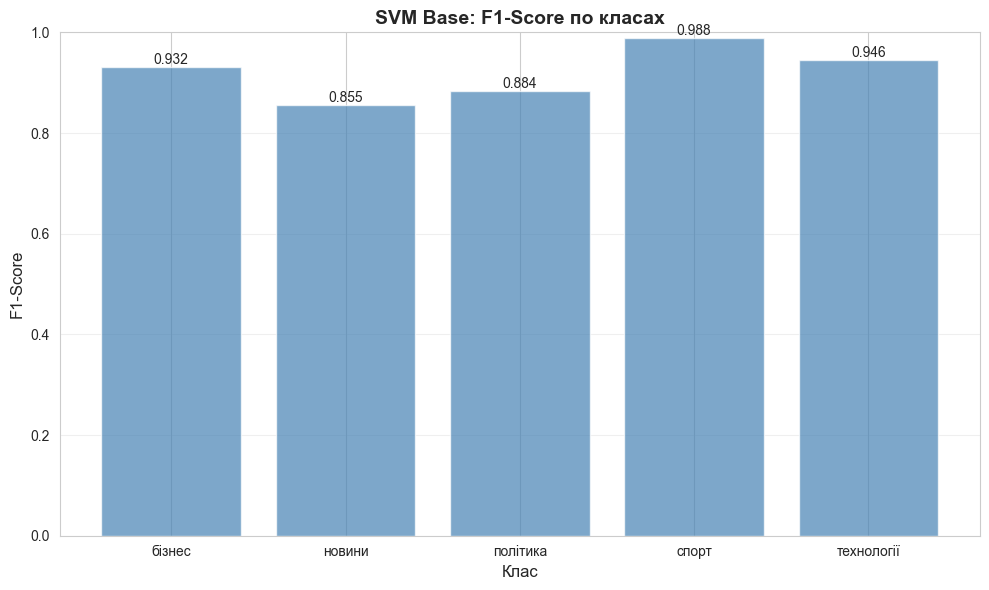

In [17]:
# Барплот F1-score по класах
plt.figure(figsize=(10, 6))
bars = plt.bar(classes, per_class_f1, color='steelblue', alpha=0.7)
plt.xlabel('Клас', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.title('SVM Base: F1-Score по класах', fontsize=14, fontweight='bold')
plt.ylim(0, 1)
plt.grid(True, axis='y', alpha=0.3)

# Додавання значень на стовпчики
for bar, val in zip(bars, per_class_f1):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(f'{plots_dir}04_topic_svm_base_f1_per_class.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## 9. Топ-15 найважливіших слів для кожного класу

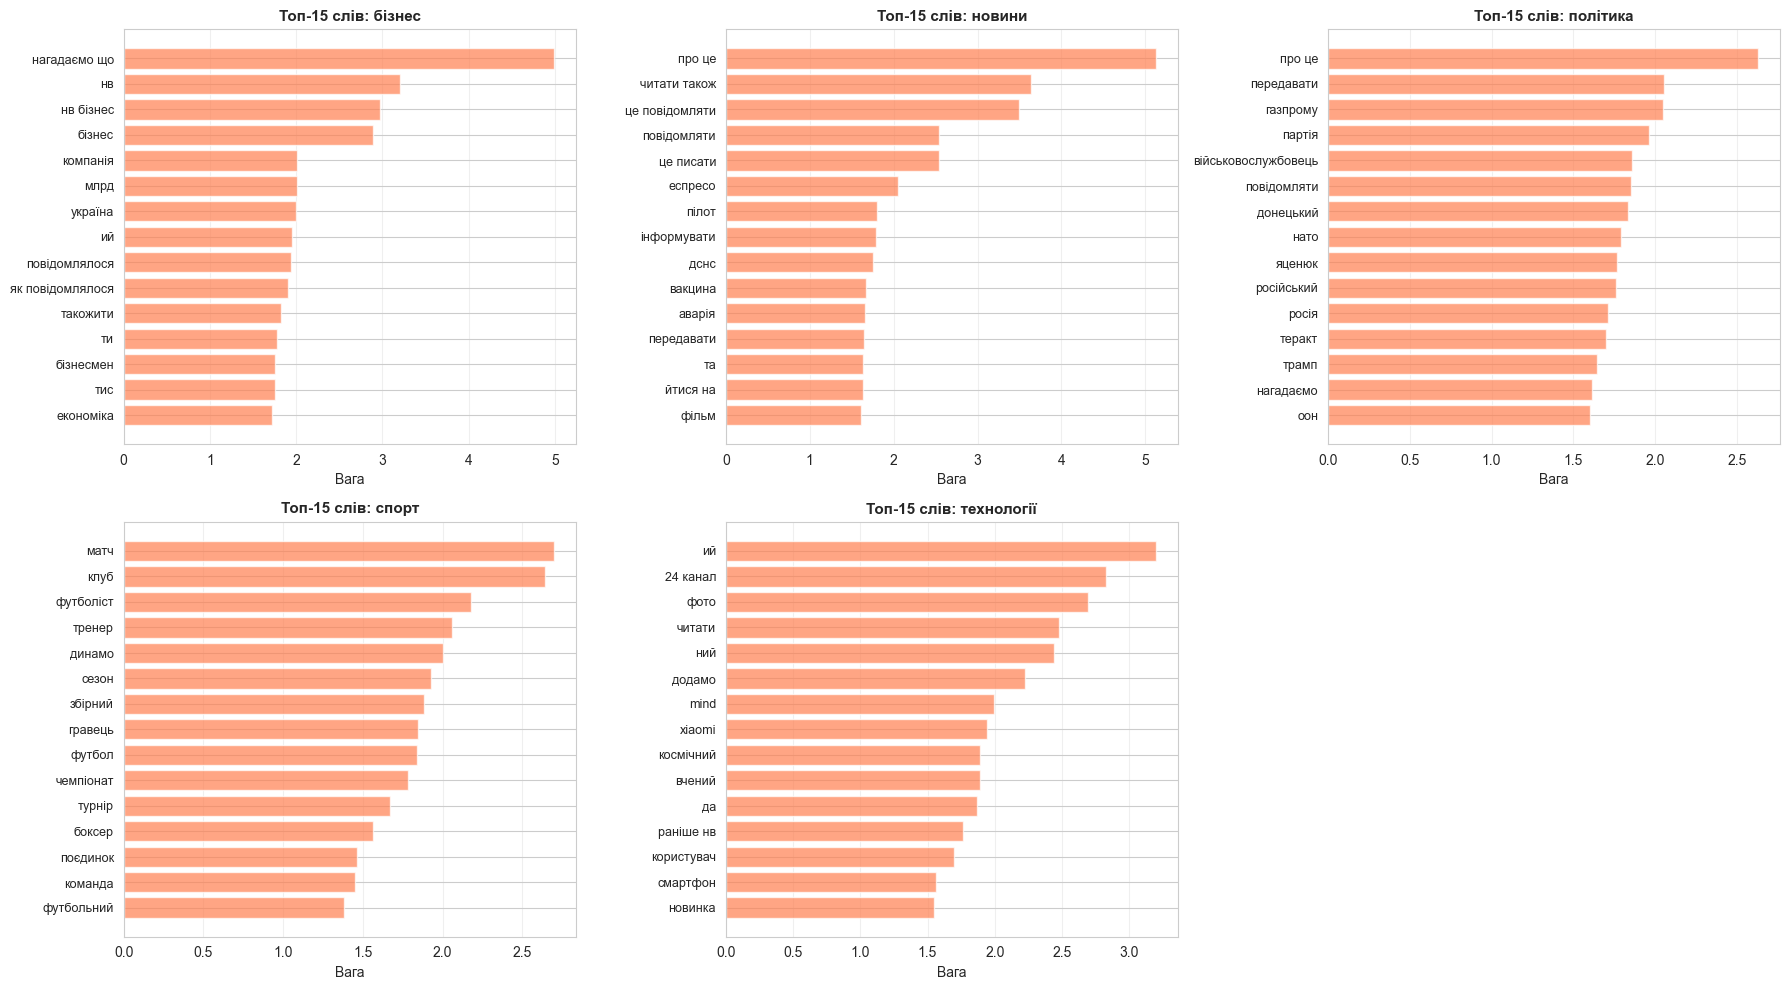

In [18]:
# Отримання ваг з базової моделі SVM
# CalibratedClassifierCV містить список базових оцінювачів
base_estimator = model.calibrated_classifiers_[0].estimator
feature_names = vectorizer.get_feature_names_out()

# Створення 5 subplots (по одному на клас)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, cls in enumerate(classes):
    # Отримання ваг для класу
    coefs = base_estimator.coef_[idx]
    top_indices = np.argsort(coefs)[-15:][::-1]  # Топ-15
    top_words = [feature_names[i] for i in top_indices]
    top_weights = coefs[top_indices]
    
    # Побудова графіку
    axes[idx].barh(range(15), top_weights, color='coral', alpha=0.7)
    axes[idx].set_yticks(range(15))
    axes[idx].set_yticklabels(top_words, fontsize=9)
    axes[idx].invert_yaxis()
    axes[idx].set_xlabel('Вага', fontsize=10)
    axes[idx].set_title(f'Топ-15 слів: {cls}', fontsize=11, fontweight='bold')
    axes[idx].grid(True, axis='x', alpha=0.3)

# Видалення зайвого subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig(f'{plots_dir}04_topic_svm_base_top_words.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## 10. Збереження моделі та результатів

In [19]:
# Збереження моделі та векторизатора
with open(f'{models_dir}topic_svm_base_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open(f'{models_dir}topic_svm_base_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

# Збереження метрик
metrics = {
    'accuracy': float(accuracy),
    'macro_f1': float(macro_f1),
    'weighted_f1': float(weighted_f1),
    'per_class_f1': {cls: float(f1) for cls, f1 in zip(classes, per_class_f1)}
}

with open(f'{results_dir}04_topic_svm_base_results.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

print("=== Модель та результати збережено ===")
print(f"Модель: {models_dir}topic_svm_base_model.pkl")
print(f"Векторизатор: {models_dir}topic_svm_base_vectorizer.pkl")
print(f"Результати: {results_dir}04_topic_svm_base_results.json")

=== Модель та результати збережено ===
Модель: saved_models/topic_svm_base_model.pkl
Векторизатор: saved_models/topic_svm_base_vectorizer.pkl
Результати: results/04_topic_svm_base_results.json


## 11. Висновки

Створено baseline модель для класифікації новин за 5 темами використовуючи:
- LinearSVC з калібрацією ймовірностей
- TF-IDF векторизацію з біграмами
- Лематизацію українського тексту
- Видалення стоп-слів

Модель навчена на повному збалансованому датасеті (5 класів) і буде використана як baseline для подальших експериментів.